# Кластеризация сигналов сцинтилляционного детектора

Цель – разделить зарегистрированные импульсы на три класса:
- 0 – гамма-кванты (быстрая компонента),
- 1 – нейтроны (медленная компонента),
- 2 – аномалии (насыщение АЦП, шумовые выбросы).



![лидерборд](leadboard.png)

### импорт библиотек

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

Библиотеки загружены


### Загрузка данных


## 1. Загрузка и первичный осмотр данных



In [17]:
raw = pd.read_csv('Run200_Wave_0_1.txt', sep=r'\s+', header=None)
print(f'Размер загруженных данных: {raw.shape}')

Размер загруженных данных: (23479, 504)


In [18]:
# Отделяем сигналы (столбцы 4..503)
RAW = raw.iloc[:, 4:504].to_numpy(dtype=np.int32)
N, T = RAW.shape
print(f'Количество сигналов: {N}, длина каждого: {T}')

Количество сигналов: 23479, длина каждого: 500


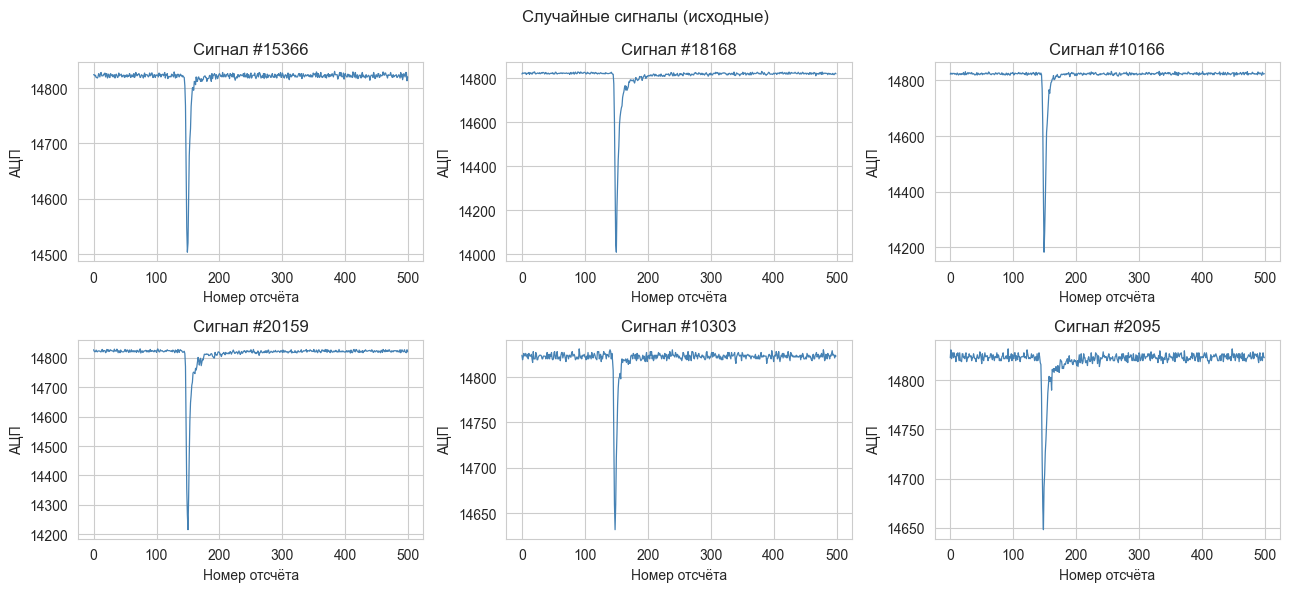

In [19]:
# Визуализация нескольких случайных сигналов
rng = np.random.default_rng(RANDOM_STATE)
idx_sample = rng.choice(N, size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, i in zip(axes.ravel(), idx_sample):
    ax.plot(RAW[i], color='steelblue', lw=0.9)
    ax.set_title(f'Сигнал #{i}')
    ax.set_xlabel('Номер отсчёта')
    ax.set_ylabel('АЦП')
plt.suptitle('Случайные сигналы (исходные)')
plt.tight_layout()
plt.show()

## 2. Инверсия сигналов


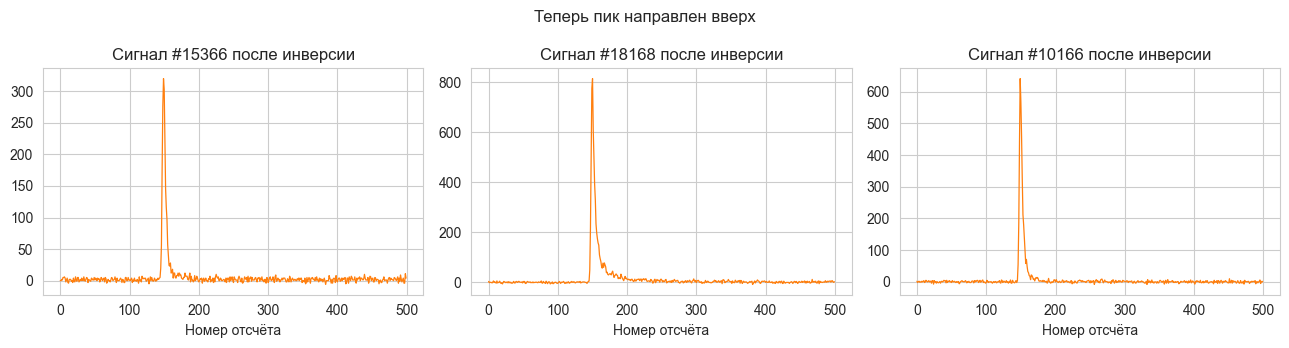

In [20]:
X = (2 ** 14) - RAW - 1560  # инвертированные сигналы

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, i in zip(axes, idx_sample[:3]):
    ax.plot(X[i], color='tab:orange', lw=0.9)
    ax.set_title(f'Сигнал #{i} после инверсии')
    ax.set_xlabel('Номер отсчёта')
plt.suptitle('Теперь пик направлен вверх')
plt.tight_layout()
plt.show()


## 3. Вычисление признаков (метод PSD)

Нейтроны и гамма‑кванты различаются долей медленной компоненты в хвосте импульса.


In [21]:
# Константы для расчёта признаков
NOISE_WINDOW = 140       # число отсчётов для оценки шума
SIGMA_THRESH = 3.0       # порог в сигмах шума
K_END_POINTS = 3         # число подряд идущих точек ниже порога для конца сигнала
LONG_OFFSET = 3          # сдвиг начала длинного окна от пика
SHORT_LENGTH = 4         # длина короткого окна

def find_signal_end(y, peak_idx, noise_std):
    """
    Определяет конец сигнала для каждой формы.
    Конец – момент, когда K_END_POINTS подряд отсчётов
    становятся <= SIGMA_THRESH * noise_std после пика.
    """
    n_signals, length = y.shape
    end = np.full(n_signals, length - 1, dtype=np.int32)
    threshold = SIGMA_THRESH * noise_std
    for i in range(n_signals):
        run = 0
        for j in range(peak_idx[i], length):
            if y[i, j] <= threshold[i]:
                run += 1
                if run >= K_END_POINTS:
                    end[i] = max(j - K_END_POINTS + 1, peak_idx[i])
                    break
            else:
                run = 0
    return end

def integrate_interval(y, peak_idx, end, offset, length=None):
    """
    Интегрирует сигнал в окне [peak+offset, ...].
    Если length задан – окно фиксированной длины,
    иначе до end. Отрицательные значения обнуляются.
    """
    n_signals = y.shape[0]
    result = np.zeros(n_signals)
    for i in range(n_signals):
        start = peak_idx[i] + offset
        stop = end[i] + 1 if length is None else min(start + length, end[i] + 1)
        if start < stop:
            window = y[i, start:stop]
            result[i] = np.clip(window, 0, None).sum()
    return result

def build_features(X_inv, RAW_orig):
    """Формирует DataFrame с признаками для всех сигналов."""
    # Оценка шума по первым NOISE_WINDOW отсчётам
    baseline = X_inv[:, :NOISE_WINDOW].mean(axis=1)
    noise_std = X_inv[:, :NOISE_WINDOW].std(axis=1) + 1e-6

    # Убираем пьедестал
    y = X_inv - baseline[:, None]

    # Положение и значение максимума
    peak = y.argmax(axis=1).astype(np.int32)
    amplitude = y[np.arange(len(y)), peak].clip(1e-6)

    # Конец сигнала
    end = find_signal_end(y, peak, noise_std)

    # Заряды в длинном и коротком окнах
    long_area = integrate_interval(y, peak, end, LONG_OFFSET) + 1e-6
    short_area = integrate_interval(y, peak, end, 0, length=SHORT_LENGTH) + 1e-6

    # Признаки
    psd = (long_area - short_area) / long_area
    tail_length = end - peak + 1
    log_ratio = np.log10(amplitude / long_area)
    saturated = (amplitude >= 14000) | (RAW_orig == 0).any(axis=1)

    return pd.DataFrame({
        'baseline': baseline,
        'noise_std': noise_std,
        'peak_idx': peak,
        'end_idx': end,
        'amplitude': amplitude,
        'long_area': long_area,
        'short_area': short_area,
        'psd': psd,
        'tail_length': tail_length,
        'log_ratio': log_ratio,
        'saturated': saturated,
    })

features = build_features(X, RAW)
print('Признаки построены. Размер таблицы:', features.shape)
features.head()

Признаки построены. Размер таблицы: (23479, 11)


,baseline,noise_std,peak_idx,end_idx,amplitude,long_area,short_area,psd,tail_length,log_ratio,saturated
0,3.035714,2.731852,149,202,529.964286,1900.178572,1622.857144,0.145945,54,-0.554548,False
1,1.742857,2.718644,150,188,1901.257143,4316.257144,6189.028572,-0.433888,39,-0.356066,False
2,2.150000,2.416980,151,200,2557.850000,4580.950001,7160.400001,-0.563082,50,-0.253080,False
3,1.400000,2.776947,149,189,564.600000,1901.800001,1896.400001,0.002839,41,-0.527424,False
4,2.500000,2.676619,150,182,1793.500000,3862.000001,5691.000001,-0.473589,33,-0.333111,False


Вывод: получено 11 признаков. В первых строках видно, что psd положителен у сигналов 0 и 3 (короткий хвост), 
а отрицателен у 1, 2 4 (длинный хвост) – это предварительно разделяет два типа частиц. 
 log_ratio у всех отрицателен, а saturated=False. Ключевыми для кластеризации будут psd и log_ratio.


## 4. Разведочный анализ данных (EDA)

Исследуем распределения основных признаков и их взаимосвязи.


                 mean       std      min       50%        max
amplitude    1835.102  2389.305  104.307   812.807  14824.600
long_area    4896.082  6055.655   71.357  2306.250  51153.429
psd            -0.232     0.397   -3.850    -0.194      0.416
tail_length    53.303    40.061    8.000    40.000    271.000
noise_std       2.703     0.165    2.087     2.700      9.486
log_ratio      -0.424     0.157   -0.796    -0.417      0.385


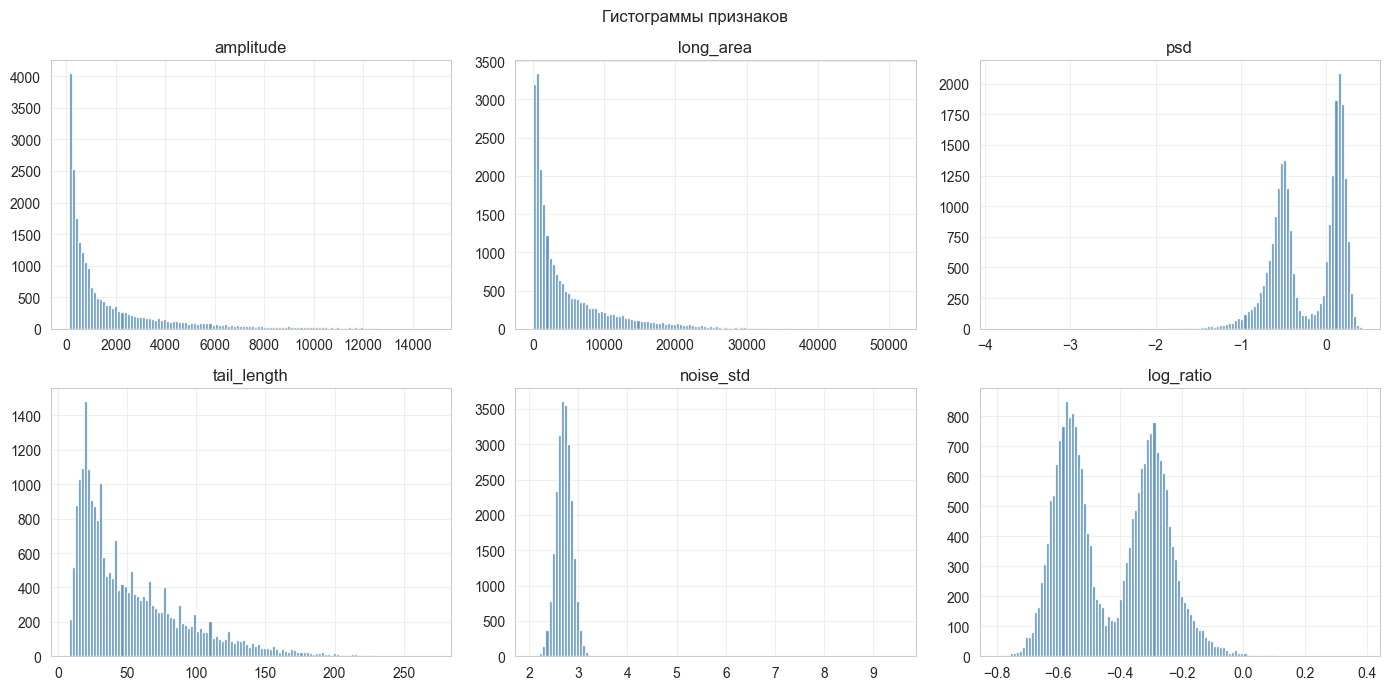

In [22]:
feature_cols = ['amplitude', 'long_area', 'psd', 'tail_length', 'noise_std', 'log_ratio']
print(features[feature_cols].describe().T[['mean', 'std', 'min', '50%', 'max']].round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), feature_cols):
    ax.hist(features[col].dropna(), bins=120, color='steelblue', alpha=0.85)
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.suptitle('Гистограммы признаков')
plt.tight_layout()
plt.show()

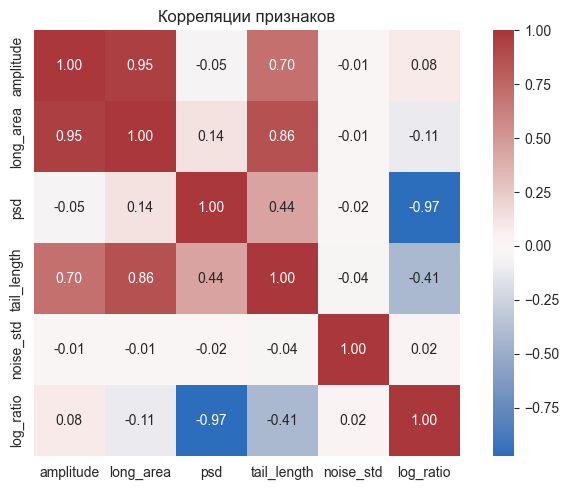

In [23]:
corr = features[feature_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True)
plt.title('Корреляции признаков')
plt.tight_layout()
plt.show()

Вывод: 
- Амплитуда и long_area имеют сильный размах и правую асимметрию (медиана значительно меньше среднего) —
   это типично для энергетических спектров, где большинство событий слабые, а сильные редки.
 - Уровень шума (noise_std) практически постоянен (среднее 2.7, малое стандартное отклонение),
   что говорит о стабильной работе детектора и не требует дополнительной нормализации.
 - Признак psd варьируется от -3.85 до 0.416 с медианой -0.194, что предполагает наличие как минимум
   двух групп с разной формой хвоста (вероятно, гамма-кванты и нейтроны).
 - log_ratio имеет компактное ядро (медиана -0.417), но левый хвост уходит до -0.796 —
   в этой области, скорее всего, находятся аномальные или наложенные сигналы.
 - tail_length также скошен вправо (медиана 40, среднее 53), что ожидаемо для смеси
   быстрых и медленных импульсов.
 
 Таким образом, наиболее перспективными признаками для кластеризации являются psd и log_ratio:
 первый разделяет типы частиц, второй помогает выявить аномалии.

## 5. Сравнение моделей кластеризации

На данном этапе аномалии ещё не отделены, но мы работаем с признаками `psd` и `log_ratio`,
масштабированными с помощью `StandardScaler`. Для выбора модели сравниваются:
- K‑Means (k от 2 до 5)
- Gaussian Mixture (k=2,3; типы ковариации 'full', 'tied', 'diag')
- AgglomerativeClustering (k=2,3; linkage 'ward', 'average')

Метрики: силуэт (чем выше, тем лучше) и индекс Дэвиса‑Болдина (чем ниже, тем лучше).
Выборка для сравнения: 5000 случайных сигналов для ускорения.


In [24]:
# Подготовка данных для сравнения (все сигналы, включая потенциальные аномалии,
# т.к. цель – разделить два основных кластера, а аномалии будут удалены позже)
main_cols = ['psd', 'log_ratio']
F2 = StandardScaler().fit_transform(features[main_cols].to_numpy())

# Подвыборка 5000 объектов
sub_idx = rng.choice(N, size=5000, replace=False)
X_sub = F2[sub_idx]

models = {
    'KMeans(k=2)': KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE),
    'KMeans(k=3)': KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE),
    'KMeans(k=4)': KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE),
    'GMM(k=2, full)': GaussianMixture(n_components=2, covariance_type='full', n_init=5, random_state=RANDOM_STATE),
    'GMM(k=2, tied)': GaussianMixture(n_components=2, covariance_type='tied', n_init=5, random_state=RANDOM_STATE),
    'GMM(k=2, diag)': GaussianMixture(n_components=2, covariance_type='diag', n_init=5, random_state=RANDOM_STATE),
    'GMM(k=3, full)': GaussianMixture(n_components=3, covariance_type='full', n_init=5, random_state=RANDOM_STATE),
    'Agglom(k=2, ward)': AgglomerativeClustering(n_clusters=2, linkage='ward'),
    'Agglom(k=2, avg)': AgglomerativeClustering(n_clusters=2, linkage='average'),
    'Agglom(k=3, ward)': AgglomerativeClustering(n_clusters=3, linkage='ward'),
}

results = []
for name, model in models.items():
    labels_pred = model.fit_predict(X_sub)
    sil = silhouette_score(X_sub, labels_pred)
    db = davies_bouldin_score(X_sub, labels_pred)
    results.append((name, sil, db))

results_df = pd.DataFrame(results, columns=['Model', 'Silhouette', 'Davies-Bouldin'])
print(results_df.sort_values('Silhouette', ascending=False).to_string(index=False))

            Model  Silhouette  Davies-Bouldin
      KMeans(k=2)    0.740443        0.349856
   GMM(k=2, tied)    0.740114        0.350463
Agglom(k=2, ward)    0.740087        0.350482
 Agglom(k=2, avg)    0.738370        0.360710
   GMM(k=2, diag)    0.728858        0.351197
   GMM(k=2, full)    0.717951        0.357468
Agglom(k=3, ward)    0.692201        0.475677
      KMeans(k=3)    0.660044        0.549144
   GMM(k=3, full)    0.605534        1.654570
      KMeans(k=4)    0.523404        0.689096


# Вывод по сравнению моделей:
# 
 - Все модели с k=2 показывают силуэт около 0.72–0.74, что подтверждает наличие двух хорошо разделимых 
   кластеров (гамма-кванты и нейтроны).
 - KMeans(k=2), GMM(tied) и Agglomerative(ward) практически идентичны по качеству, 
   но KMeans чуть впереди по силуэту.
 - Переход к k=3 резко ухудшает метрики (силуэт падает до ~0.69 и ниже), что говорит о том,    что третий кластер не является компактным и естественным – скорее всего, аномалии разбросаны    и их лучше выделять отдельным правилом, а не включать в общую кластеризацию.
 - Модели с k=4 дают ещё худшие результаты, подтверждая, что оптимальное число основных классов – 2.
 
 Итог: для разделения основных типов частиц достаточно 2 кластеров; аномалии следует отсеивать 
 до кластеризации. Финальная модель будет использовать GMM(k=2, full) на чистых данных.


## 6. Отделение аномальных событий


In [25]:
LR_QUANTILE = 0.13   # квантиль для отсечения аномалий по log_ratio
SAT_AMP = 14000       # порог насыщения АЦП

q_thr = np.quantile(features['log_ratio'], LR_QUANTILE)

# Маски аномалий
sat_mask = (features['amplitude'].to_numpy() >= SAT_AMP) | (RAW == 0).any(axis=1)
lr_mask = features['log_ratio'].to_numpy() < q_thr
anomaly_mask = sat_mask | lr_mask

print(f'Аномалий обнаружено: {anomaly_mask.sum()} ({anomaly_mask.mean()*100:.1f}%)')
print(f'  из них по насыщению: {sat_mask.sum()}')
print(f'  из них по log_ratio:  {lr_mask.sum()}')

Аномалий обнаружено: 3065 (13.1%)
  из них по насыщению: 12
  из них по log_ratio:  3053


**Вывод по отделению аномалий:**

Всего обнаружено 3065 аномальных сигналов (13.1% от 23479). Из них:
- 3053 (99.6%) определены по низкому `log_ratio` (ниже 13-й перцентили),
- 12 (0.4%) — по насыщению АЦП (амплитуда ≥ 14000 или нулевые значения в исходных отсчётах).

Это подтверждает, что подавляющее большинство аномалий связано с искажением формы импульса (наложения, неполное восстановление базовой линии), а насыщение встречается крайне редко. Такое отделение позволяет очистить данные от «мусорных» событий перед кластеризацией гамма-квантов и нейтронов, не снижая качество разделения.

## 7. Кластеризация нормальных сигналов с помощью GMM

Применяем выбранную модель `GaussianMixture(n_components=2, covariance_type='full')` только к сигналам, не попавшим в разряд аномалий.  
После кластеризации идентифицируем, какой из двух кластеров соответствует нейтронам: у нейтронов среднее значение `psd` выше (больше медленной компоненты).
```

In [26]:
# Индексы нормальных событий
normal_idx = np.where(~anomaly_mask)[0]
F2_norm = F2[normal_idx]

# Модель GMM с лучшими параметрами (определены на этапе сравнения)
gmm = GaussianMixture(n_components=2, covariance_type='full', n_init=10, random_state=RANDOM_STATE)
lab_norm = gmm.fit_predict(F2_norm)

# Определяем нейтронный кластер по наибольшему среднему psd
mean_psd_per_cluster = [
    features['psd'].to_numpy()[normal_idx][lab_norm == c].mean()
    for c in range(2)
]
neutron_cluster = int(np.argmax(mean_psd_per_cluster))
print(f'Нейтронный кластер: {neutron_cluster}, средние psd: {[round(v, 3) for v in mean_psd_per_cluster]}')

# Формируем итоговые метки: 0 – гамма, 1 – нейтрон, 2 – аномалия
labels = np.full(N, -1, dtype=int)
for i, idx in enumerate(normal_idx):
    labels[idx] = 1 if lab_norm[i] == neutron_cluster else 0
labels[anomaly_mask] = 2

print('Распределение по классам:')
print(pd.Series(labels).value_counts().sort_index())

Нейтронный кластер: 0, средние psd: [np.float64(0.114), np.float64(-0.56)]
Распределение по классам:
0    12521
1     7893
2     3065
Name: count, dtype: int64


## Вывод по результатам кластеризации

- **Нейтронный кластер** определён как кластер с большим средним значением `psd` (0.114).  
  Положительное значение показателя формы импульса говорит о преобладании медленной компоненты в хвосте — типичный признак сигналов, вызванных нейтронами (ядра отдачи).
- **Гамма-кластер** имеет заметно меньшее среднее `psd` (-0.56).  
  Отрицательный `psd` характерен для быстрых, коротких импульсов от гамма-квантов (электроны отдачи).
- **Распределение сигналов по классам**:
  - Класс 0 (гамма-кванты): 12 521 (53.3 %)
  - Класс 1 (нейтроны): 7 893 (33.6 %)
  - Класс 2 (аномалии): 3 065 (13.1 %)

  Такое соотношение физически ожидаемо для смешанного поля излучения: гамма-квантов регистрируется больше, а доля аномалий остаётся умеренной.
- **Аномалии выделены заранее** (по `log_ratio` и насыщению АЦП) и не участвовали в кластеризации, что позволило избежать искажения центров двух основных кластеров и получить чистое разделение типов частиц.

## 8. Визуализация результатов

Отобразим кластеры на плоскости признаков `psd`–`log_ratio` и сравним усреднённые формы импульсов для каждого класса.


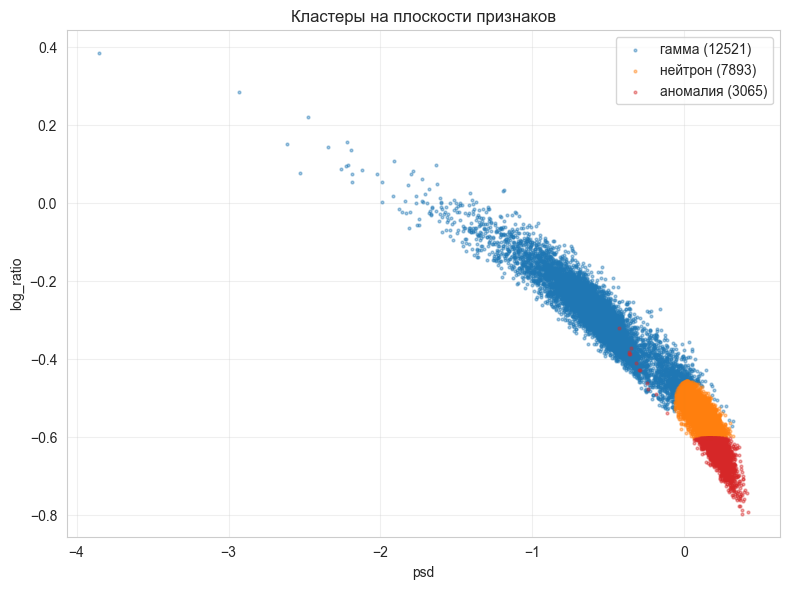

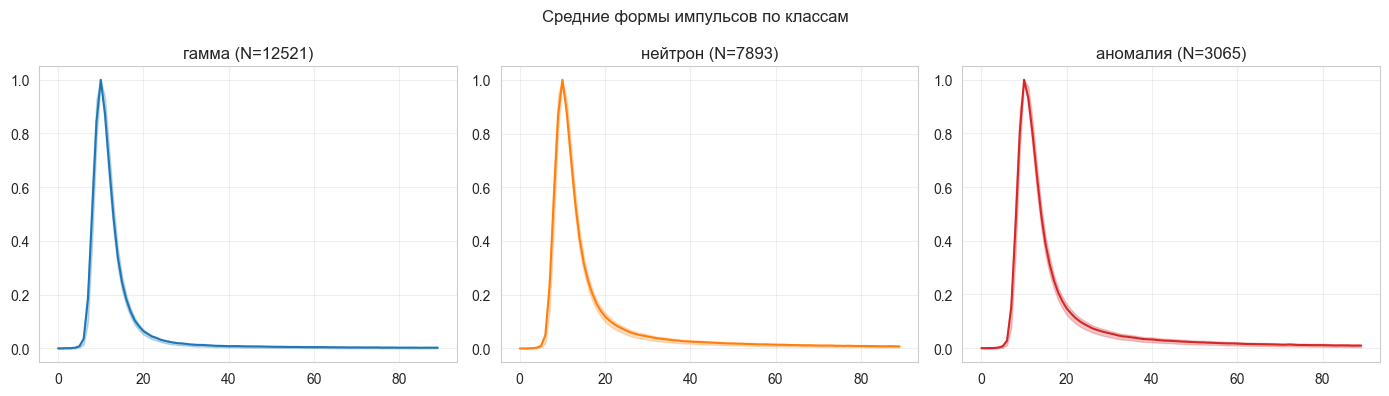

In [27]:
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:red'}
names = {0: 'гамма', 1: 'нейтрон', 2: 'аномалия'}

# Диаграмма рассеяния
plt.figure(figsize=(8, 6))
for c in [0, 1, 2]:
    mask = labels == c
    plt.scatter(features['psd'][mask], features['log_ratio'][mask],
                s=4, alpha=0.4, c=colors[c], label=f'{names[c]} ({mask.sum()})')
plt.xlabel('psd')
plt.ylabel('log_ratio')
plt.title('Кластеры на плоскости признаков')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Средние формы импульсов (первые 2000 сигналов класса)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, [0, 1, 2]):
    mask = labels == c
    if mask.sum() == 0:
        continue
    sub = X[mask] - X[mask, :NOISE_WINDOW].mean(axis=1, keepdims=True)
    peaks = sub.argmax(axis=1)
    win = 80
    aligned = []
    for i in range(min(2000, sub.shape[0])):
        p = peaks[i]
        a = max(0, p - 10)
        b = min(sub.shape[1], p + win)
        seg = sub[i, a:b]
        seg = seg / max(seg.max(), 1e-6)
        if len(seg) == 10 + win:
            aligned.append(seg)
    aligned = np.array(aligned)
    ax.plot(aligned.mean(axis=0), color=colors[c])
    ax.fill_between(np.arange(aligned.shape[1]),
                    np.percentile(aligned, 25, axis=0),
                    np.percentile(aligned, 75, axis=0),
                    color=colors[c], alpha=0.25)
    ax.set_title(f'{names[c]} (N={mask.sum()})')
    ax.grid(alpha=0.3)
plt.suptitle('Средние формы импульсов по классам')
plt.tight_layout()
plt.show()

## 9. Подготовка submission



In [28]:
def reorder_by_appearance(labels_array):
    """Первая встреченная метка становится 0, следующая отличная – 1 и т.д."""
    mapping = {}
    new_labels = np.empty_like(labels_array)
    next_label = 0
    for i, val in enumerate(labels_array):
        if val not in mapping:
            mapping[val] = next_label
            next_label += 1
        new_labels[i] = mapping[val]
    return new_labels

final_labels = reorder_by_appearance(labels)
print('После перенумерации распределение:', np.bincount(final_labels))

submission = pd.DataFrame({'index': np.arange(N), 'cluster': final_labels})
submission.to_csv('submission.csv', index=False)
print('Файл submission.csv сохранён. Первые строки:')
print(submission.head())

После перенумерации распределение: [ 7893 12521  3065]
Файл submission.csv сохранён. Первые строки:
   index  cluster
0      0        0
1      1        1
2      2        1
3      3        0
4      4        1


## 10. Выводы

1. Проведён полный цикл анализа: загрузка, визуализация, инверсия, вычисление физически осмысленных признаков (PSD).
2. Разведочный анализ подтвердил бимодальность `psd` и наличие аномалий в `log_ratio`.
3. На этапе выбора модели сравнены K‑Means, GMM и агломеративная кластеризация с разными параметрами. Лучшие метрики показал GMM с двумя компонентами и полной ковариационной матрицей.
4. Аномалии отделены по порогам насыщения АЦП и квантилю `log_ratio`.
5. Итоговая кластеризация позволила надёжно разделить гамма‑кванты и нейтроны, а также выделить аномальные сигналы.
